In [ ]:
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu128 -q
!pip install fair-esm -q
!pip install git+https://github.com/facebookresearch/esm.git  # bleeding edge, current repo main branch
!pip install biopython -q
!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.8.0+cu128.html -q
!sudo apt-get update -qq
!sudo DEBIAN_FRONTEND=noninteractive apt-get install -y -qq dssp
!sudo ln -s /usr/bin/mkdssp /usr/bin/dssp

import torch
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser, Selection, PDBList, DSSP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.data import Data

In [26]:
from Bio.Data.PDBData import protein_letters_3to1 as three_to_one
from Bio.PDB import PDBParser, Selection


In [ ]:
import numpy as np
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser, DSSP, Selection
from Bio.Data.PDBData import protein_letters_3to1 as three_to_one
import torch
from torch_geometric.data import Data

VDW_CUTOFF = 8.0
HBOND_ENERGY_THRESHOLD = -0.5
PEPTIDE_BOND_CUTOFF = 1.5  # Å — C(i) to N(i+1), ideal ~1.33Å

STANDARD_AA = {
    "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL"
}

# Edge type → integer label (for concatenation later)
EDGE_TYPE_MAP = {"peptide": 0, "vdw": 1, "hbond": 2}


class ProteinGraphBuilder:
    def __init__(self, pdb_path: str):
        self.pdb_path = pdb_path

        # --- Parse structure ---
        parser = PDBParser(QUIET=True)
        self.structure = parser.get_structure("protein", pdb_path)
        self.model = next(self.structure.get_models())

        self._raw_residues = [
            r for r in Selection.unfold_entities(self.model, "R")
            if "CA" in r
        ]

        # --- Sequence extraction + index mapping ---
        self.sequence, self.valid_indices, self.skipped = self._extract_sequence()

        # Final residue list — only standard AA residues, aligned to sequence
        self.residues = [self._raw_residues[i] for i in self.valid_indices]
        self.res_to_idx = {r: i for i, r in enumerate(self.residues)}

        # Precompute once — used by vdw_edges
        self._cb_coords = self._get_cb_coords()

        # Build DSSP → node index map once — used by hbond_edges
        self._dssp_to_node_idx = self._build_dssp_map()

        print(f"[ProteinGraphBuilder] {len(self.residues)} residues | "
              f"sequence length: {len(self.sequence)}")
        if self.skipped:
            print(f"  Skipped: {[(i, r.get_resname(), reason) for i, r, reason in self.skipped]}")

    # ------------------------------------------------------------------
    # Sequence extraction
    # ------------------------------------------------------------------

    def _extract_sequence(self) -> tuple[str, list[int], list]:
        sequence, valid_indices, skipped = [], [], []

        for i, res in enumerate(self._raw_residues):
            resname = res.get_resname().strip()
            het, resseq, icode = res.get_id()

            if het.strip():
                skipped.append((i, res, "HETATM"))
                continue
            if resname not in STANDARD_AA:
                skipped.append((i, res, f"non-standard: {resname}"))
                continue
            try:
                one_letter = three_to_one[resname]
            except KeyError:
                skipped.append((i, res, "no one-letter code"))
                continue
            if icode.strip():
                print(f"  [insertion] resseq={resseq} icode={icode} ({resname}) at index {i}")

            sequence.append(one_letter)
            valid_indices.append(i)

        return "".join(sequence), valid_indices, skipped

    # ------------------------------------------------------------------
    # Coordinate helpers
    # ------------------------------------------------------------------

    def _get_cb_coords(self) -> np.ndarray:
        """
        Cβ for all standard residues, Cα fallback for Glycine.
        Precomputed once at init — do not call this repeatedly.
        """
        coords = []
        for res in self.residues:
            atom = res["CB"] if "CB" in res else res["CA"]
            coords.append(atom.get_vector().get_array())
        return np.array(coords)  # (N, 3)

    # ------------------------------------------------------------------
    # DSSP → node index mapping
    # ------------------------------------------------------------------

    def _build_dssp_map(self) -> dict:
        """
        Maps each DSSP key (chain_id, res_id) → node index in self.residues.
        DSSP may drop terminal residues or residues it can't assign, so this
        mapping will be partial — missing entries are silently skipped in hbond_edges.
        """
        dssp_map = {}
        for res in self.residues:
            chain_id = res.get_parent().id
            res_id = res.get_id()          # (het, resseq, icode)
            dssp_key = (chain_id, res_id)
            node_idx = self.res_to_idx[res]
            dssp_map[dssp_key] = node_idx
        return dssp_map

    # ------------------------------------------------------------------
    # Edge builders
    # ------------------------------------------------------------------

    def peptide_edges(self) -> list[tuple]:
        """
        Consecutive residues in the same chain connected by a real C→N bond.
        Checks atomic distance to exclude chain breaks (missing residues in PDB).
        Weight is fixed at 1.0 — covalent bonds are binary.
        """
        edges = []
        for i in range(len(self.residues) - 1):
            r1, r2 = self.residues[i], self.residues[i + 1]

            # Must be same chain
            if r1.get_parent().id != r2.get_parent().id:
                continue

            # Check actual C(i) → N(i+1) bond distance to detect chain breaks
            if "C" not in r1 or "N" not in r2:
                continue
            c_coord = r1["C"].get_vector().get_array()
            n_coord = r2["N"].get_vector().get_array()
            bond_dist = float(np.linalg.norm(c_coord - n_coord))

            if bond_dist <= PEPTIDE_BOND_CUTOFF:
                edges.append((i, i + 1, 1.0, "peptide"))

        return edges

    def vdw_edges(self) -> list[tuple]:
        """
        Residue pairs within VDW_CUTOFF Å (Cβ–Cβ distance).
        Weight is a Gaussian decay — closer residues get higher weight.
        query_pairs() already excludes self-loops and duplicate pairs.
        """
        tree = cKDTree(self._cb_coords)
        edges = []
        for i, j in tree.query_pairs(r=VDW_CUTOFF):
            dist = float(np.linalg.norm(self._cb_coords[i] - self._cb_coords[j]))
            weight = float(np.exp(-dist / VDW_CUTOFF))
            edges.append((i, j, weight, "vdw"))
        return edges

    def hbond_edges(self) -> list[tuple]:
        """
        Hydrogen bonds from DSSP (Kabsch-Sander energy < HBOND_ENERGY_THRESHOLD).
        DSSP keys are mapped back to node indices via _dssp_to_node_idx to avoid
        index misalignment between DSSP's internal ordering and self.residues.
        Weight is the absolute Kabsch-Sander energy — stronger H-bonds get higher weight.
        """
        dssp = DSSP(self.model, self.pdb_path, dssp="mkdssp", file_type="PDB")
        edges = []

        for key in dssp.keys():
            data = dssp[key]

            # Donor to acceptor and its reverse pair
            for offset_field, energy_field in [(6, 7), (8, 9)]:
                offset = data[offset_field]
                energy = data[energy_field]

                if energy >= HBOND_ENERGY_THRESHOLD or offset == 0:
                    continue

                # Resolve partner DSSP key
                dssp_keys_list = list(dssp.keys())
                src_dssp_idx = dssp_keys_list.index(key)
                partner_dssp_idx = src_dssp_idx + offset

                if not (0 <= partner_dssp_idx < len(dssp_keys_list)):
                    continue

                partner_key = dssp_keys_list[partner_dssp_idx]

                # Map both keys to node indices — skip if either is absent
                src_node = self._dssp_to_node_idx.get(key)
                dst_node = self._dssp_to_node_idx.get(partner_key)

                if src_node is None or dst_node is None:
                    continue

                edges.append((src_node, dst_node, float(abs(energy)), "hbond"))

        return edges

    # ------------------------------------------------------------------
    # Graph builder
    # ------------------------------------------------------------------

    def build(self, node_features: torch.Tensor | None = None) -> Data:
        """
        Assembles the PyG Data object.

        Args:
            node_features: (N, F) tensor of precomputed node features.
                           If None, uses zeros as placeholder.

        Returns:
            Data with:
                x          — node features (N, F)
                edge_index — (2, E) undirected
                edge_attr  — (E, 2) → [weight, edge_type_int]
        """
        all_edges = self.peptide_edges() + self.vdw_edges() + self.hbond_edges()

        src = torch.tensor([e[0] for e in all_edges], dtype=torch.long)
        dst = torch.tensor([e[1] for e in all_edges], dtype=torch.long)

        # Undirected: duplicate both directions
        edge_index = torch.stack([
            torch.cat([src, dst]),
            torch.cat([dst, src])
        ])

        weights = torch.tensor([e[2] for e in all_edges], dtype=torch.float)
        types = torch.tensor(
            [EDGE_TYPE_MAP[e[3]] for e in all_edges], dtype=torch.float
        )

        # Stack weight + type — both directions get same attributes
        edge_attr = torch.stack([weights, types], dim=1)           # (E, 2)
        edge_attr = edge_attr.repeat(2, 1)                         # (2E, 2)

        if node_features is None:
            print("[ProteinGraphBuilder] No node features provided — using zeros.")
            node_features = torch.zeros((len(self.residues), 1), dtype=torch.float)

        assert node_features.shape[0] == len(self.residues), (
            f"node_features rows {node_features.shape[0]} != "
            f"residues {len(self.residues)}"
        )

        return Data(
            x=node_features,
            edge_index=edge_index,
            edge_attr=edge_attr,
            num_nodes=len(self.residues)
        )

In [ ]:
PDBList().download_pdb_files(['101M'], pdir='.', file_format='pdb')

Structure exists: './pdb101m.ent' 


In [28]:
data = ProteinGraphBuilder('./pdb101m.pdb').build()

TypeError: 'dict' object is not callable

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_graph(G, color):
    plt.figure(figsize=(15,9))
    plt.xticks([])
    plt.yticks([])
    edge_values = [attr[1] for _, _, attr in G.edges(data="edge_attr")]
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2", edge_color= edge_values)
    plt.title("Protein Graph Visualization")
    plt.show()

In [16]:
data

Data(x=[154, 1], edge_index=[2, 2254], edge_attr=[2254])

/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


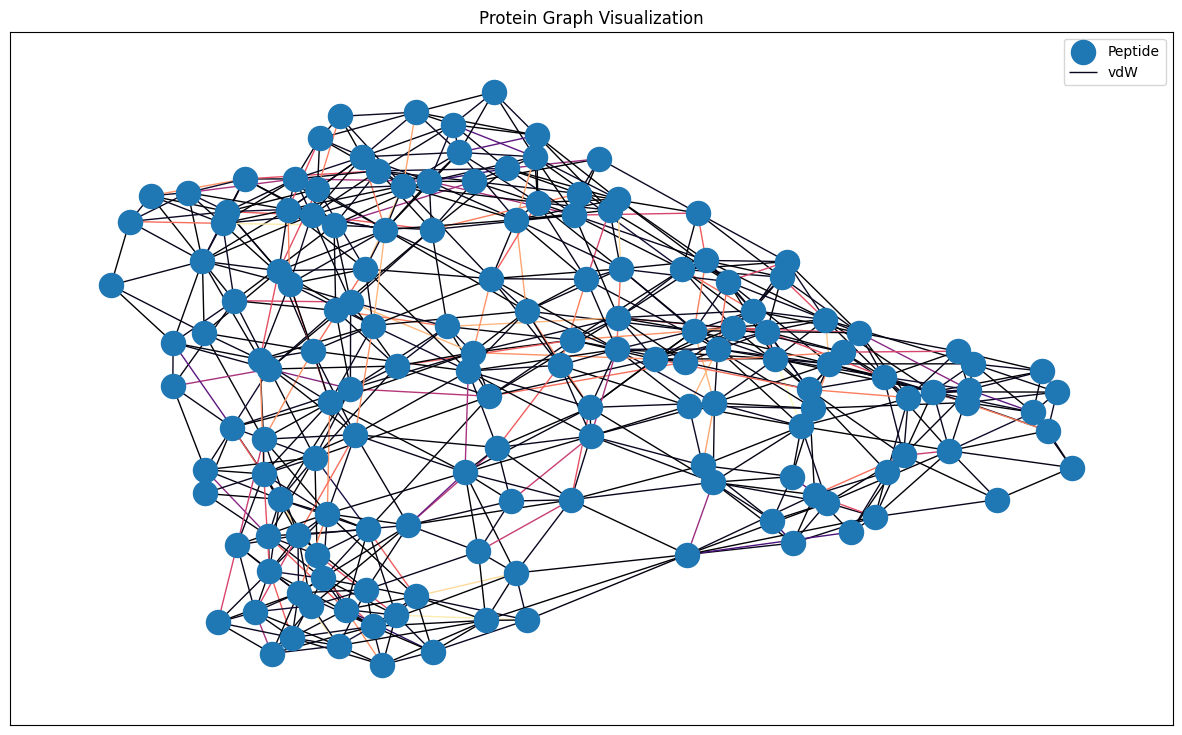

In [15]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True, edge_attrs=["edge_attr"])
visualize_graph(G, color=data.y)

In [ ]:

model, alphabet = torch.hub.load("facebookresearch/esm:main", "esm2_t33_650M_UR50D");
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results

Downloading: "https://github.com/facebookresearch/esm/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt


In [4]:
# Prepare data (first 2 sequences from ESMStructuralSplitDataset superfamily / 4)
data = [
    ("protein1", "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"),
    ("protein2", "KALTARQQEVFDLIRDHISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE"),
    ("protein2 with mask","KALTARQQEVFDLIRD<mask>ISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE"),
    ("protein3",  "K A <mask> I S Q"),
]
batch_labels, batch_strs, batch_tokens = batch_converter(data)
batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

In [28]:
results = model(batch_tokens, repr_layers=[33], return_contacts=True)
token_representations = results["representations"][33]  

In [27]:
token_representations[0][0]

tensor([ 0.0744, -0.0747,  0.0824,  ..., -0.2394,  0.1661, -0.0306])

In [8]:
token_representations.shape

torch.Size([4, 73, 1280])

In [15]:
results["contacts"].shape

torch.Size([4, 71, 71])

torch.Size([67, 67])


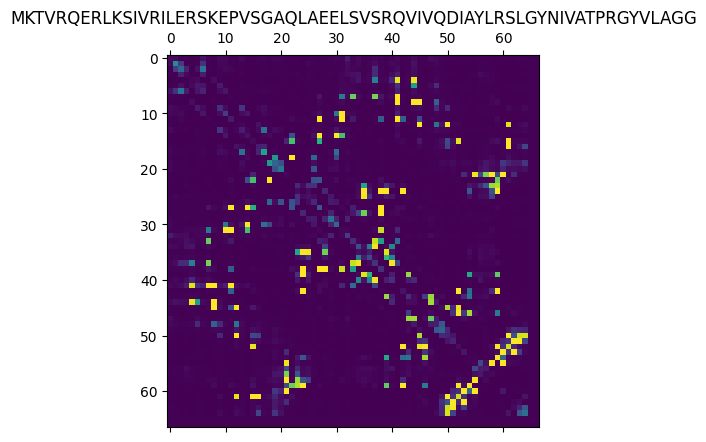

torch.Size([71, 71])


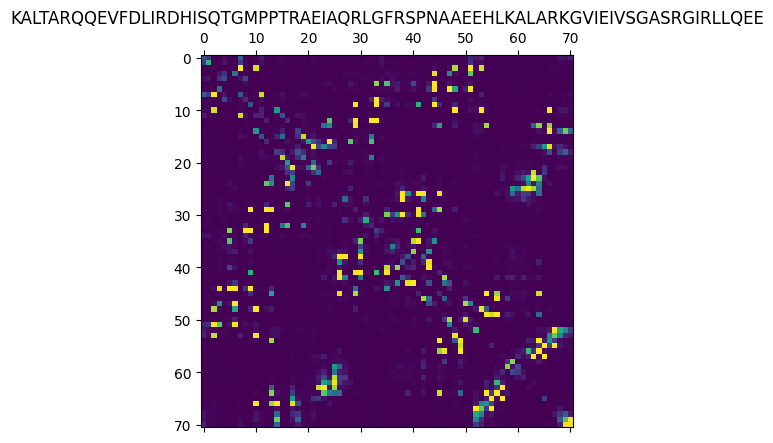

torch.Size([71, 71])


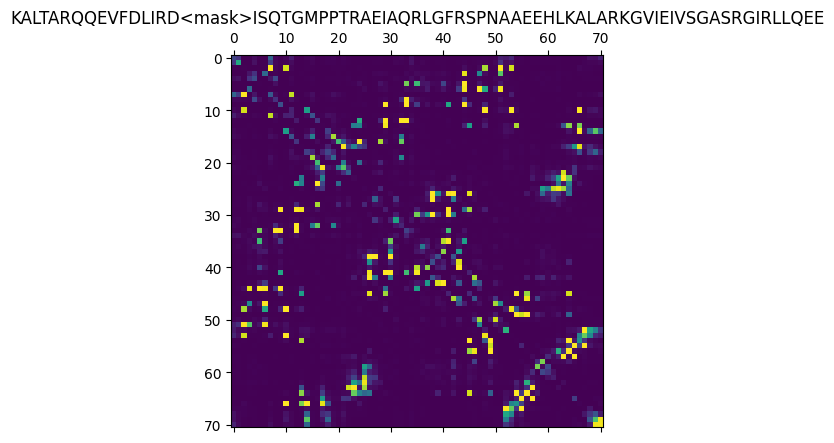

torch.Size([8, 8])


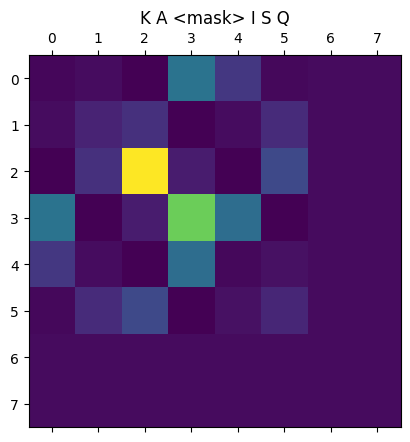

In [13]:
# Generate per-sequence representations via averaging
# NOTE: token 0 is always a beginning-of-sequence token, so the first residue is token 1.
sequence_representations = []
for i, tokens_len in enumerate(batch_lens):
    sequence_representations.append(token_representations[i, 1 : tokens_len - 1].mean(0))

# Look at the unsupervised self-attention map contact predictions
import matplotlib.pyplot as plt
for (_, seq), tokens_len, attention_contacts in zip(data, batch_lens, results["contacts"]):
    print(attention_contacts[: tokens_len, : tokens_len].shape)
    plt.matshow(attention_contacts[: tokens_len, : tokens_len])
    plt.title(seq)
    plt.show()

# Map this fucking contacts to the ones created UwU